In [63]:
import tensorflow as tf
from tensorflow.keras import models, layers
import matplotlib.pyplot as plt
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications.efficientnet import preprocess_input
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.optimizers import Adamax
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.applications import VGG16
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Dense, Flatten, Dropout
import numpy as np
from tensorflow.keras.applications import MobileNet
from tensorflow.keras.applications import EfficientNetB0
from tensorflow.keras.layers import Dense, BatchNormalization, Dropout
from tensorflow.keras.models import Model


In [64]:
target_size = (128, 128)
batch_size = 16
CHANNELS = 3

In [67]:
dataset = tf.keras.preprocessing.image_dataset_from_directory(
            r"C:\Users\DELL\Downloads\RawBalanced(3200)_alzheimers",
            shuffle = True,
            image_size = (target_size),
            batch_size = (batch_size)

    )

Found 12800 files belonging to 4 classes.


In [68]:
class_names = dataset.class_names
class_names

['MildDemented', 'ModerateDemented', 'NonDemented', 'VeryMildDemented']

In [69]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

def split_directory_data(directory, train_split=0.7, test_split=0.2, val_split=0.1, target_size=(150, 150), batch_size=32):
   
    datagen = ImageDataGenerator(rescale=1./255)

    train_generator = datagen.flow_from_directory(
        directory,
        target_size=target_size,
        batch_size=batch_size,
        class_mode='SparseCategoricalCrossentropy',  
        shuffle=True,
        seed=42
    )

    total_samples = len(train_generator.filenames)
    train_samples = int(total_samples * train_split)
    val_samples = int(total_samples * val_split)

    train_data_generator = datagen.flow_from_directory(
        directory,
        target_size=target_size,
        batch_size=batch_size,
        class_mode='categorical',  
        subset='training',
        shuffle=True,
        seed=42
    )

    val_data_generator = datagen.flow_from_directory(
        directory,
        target_size=target_size,
        batch_size=batch_size,
        class_mode='SparseCategoricalCrossentropy',  
        subset='validation',
        shuffle=True,
        seed=42
    )

    test_data_generator = datagen.flow_from_directory(
        directory,
        target_size=target_size,
        batch_size=batch_size,
        class_mode='SparseCategoricalCrossentropy',  
        subset='validation',
        shuffle=True,
        seed=42
    )

    return train_data_generator, val_data_generator, test_data_generator


In [70]:
def dataset_splitting(ds, train_split = 0.7, test_split = 0.2, val_split = 0.1, shuffle = True, shuffle_size = 1000):

  if shuffle == True:
    ds = ds.shuffle(shuffle_size, seed = 12)    
    ds_size = len(ds)
    train_size = int(train_split*ds_size)
    val_size = int(val_split*ds_size)

    train_ds = ds.take(train_size)
    val_ds = ds.skip(train_size).take(val_size)
    test_ds = ds.skip(train_size).skip(val_size)
    
    return train_ds, val_ds, test_ds

In [71]:
train_data_generator, val_data_generator, test_data_generator = dataset_splitting(dataset)

In [72]:

lr = 0.001
save_loc = 'preview/model'

mobile = MobileNet(
    include_top=False,
    input_shape=(128, 128, 3),
    pooling='max',
    weights='imagenet',
    alpha=1.0,
    depth_multiplier=1,
    dropout=0.5
)

x = mobile.layers[-1].output
x = tf.keras.layers.BatchNormalization(axis=-1, momentum=0.99, epsilon=0.001)(x)
predictions = Dense(4, activation='softmax')(x)
model = Model(inputs=mobile.input, outputs=predictions)

for layer in model.layers:
    layer.trainable = True

model.compile(optimizer=tf.keras.optimizers.Adamax(learning_rate=lr), loss='categorical_crossentropy', metrics=['accuracy'])


In [73]:
model.summary()


Model: "model_7"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 input_8 (InputLayer)        [(None, 128, 128, 3)]     0         
                                                                 
 conv1 (Conv2D)              (None, 64, 64, 32)        864       
                                                                 
 conv1_bn (BatchNormalizati  (None, 64, 64, 32)        128       
 on)                                                             
                                                                 
 conv1_relu (ReLU)           (None, 64, 64, 32)        0         
                                                                 
 conv_dw_1 (DepthwiseConv2D  (None, 64, 64, 32)        288       
 )                                                               
                                                                 
 conv_dw_1_bn (BatchNormali  (None, 64, 64, 32)        128 

 )                                                               
                                                                 
 conv_dw_8_bn (BatchNormali  (None, 8, 8, 512)         2048      
 zation)                                                         
                                                                 
 conv_dw_8_relu (ReLU)       (None, 8, 8, 512)         0         
                                                                 
 conv_pw_8 (Conv2D)          (None, 8, 8, 512)         262144    
                                                                 
 conv_pw_8_bn (BatchNormali  (None, 8, 8, 512)         2048      
 zation)                                                         
                                                                 
 conv_pw_8_relu (ReLU)       (None, 8, 8, 512)         0         
                                                                 
 conv_dw_9 (DepthwiseConv2D  (None, 8, 8, 512)         4608      
 )        

In [74]:
learning_rate = 0.0001
optimizer = Adam(learning_rate=learning_rate)

model.compile(
    optimizer=optimizer,
   loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=False),
    metrics=['accuracy']
)

In [75]:
history = model.fit(
    train_data_generator,
    batch_size=batch_size,
    validation_data=val_data_generator,
    verbose=1,
    epochs=5,
)

Epoch 1/5
560/560 [==============================] - 823s 1s/step - loss: 0.6954 - accuracy: 0.7267 - val_loss: 0.4746 - val_accuracy: 0.8211
Epoch 2/5
560/560 [==============================] - 2513s 4s/step - loss: 0.3910 - accuracy: 0.8467 - val_loss: 0.2105 - val_accuracy: 0.9148
Epoch 3/5
560/560 [==============================] - 362s 638ms/step - loss: 0.2538 - accuracy: 0.9027 - val_loss: 0.1105 - val_accuracy: 0.9617
Epoch 4/5
560/560 [==============================] - 397s 698ms/step - loss: 0.1646 - accuracy: 0.9371 - val_loss: 0.1436 - val_accuracy: 0.9422
Epoch 5/5
117/560 [=====>........................] - ETA: 5:05 - loss: 0.1196 - accuracy: 0.9583

KeyboardInterrupt: 

In [34]:
import matplotlib.pyplot as plt

history_dict = history.history

epochs = range(1, len(history_dict['loss']) + 1)
train_loss = history_dict['loss']
val_loss = history_dict['val_loss']
train_acc = history_dict.get('accuracy')  # Depending on the metric used
val_acc = history_dict.get('val_accuracy')  # Depending on the metric used


plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(epochs, train_loss, label='Training Loss')
plt.plot(epochs, val_loss, label='Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('Training and Validation Loss')
plt.legend()


if train_acc and val_acc:
    plt.subplot(1, 2, 2)
    plt.plot(epochs, train_acc, label='Training Accuracy')
    plt.plot(epochs, val_acc, label='Validation Accuracy')
    plt.xlabel('Epochs')
    plt.ylabel('Accuracy')
    plt.title('Training and Validation Accuracy')
    plt.legend()

plt.tight_layout()
plt.show()


NameError: name 'history' is not defined

In [18]:
model.evaluate(test_data_generator)

160/160 [==============================] - 32s 161ms/step - loss: 0.0480 - accuracy: 0.9848


[0.04802989214658737, 0.9847656488418579]

1/1 [==============================] - 0s 251ms/step
Predicted: VeryMildDemented
Actual: VeryMildDemented
1/1 [==============================] - 0s 173ms/step
Predicted: VeryMildDemented
Actual: VeryMildDemented
1/1 [==============================] - 0s 183ms/step
Predicted: NonDemented
Actual: NonDemented
1/1 [==============================] - 0s 222ms/step
Predicted: ModerateDemented
Actual: ModerateDemented
1/1 [==============================] - 0s 172ms/step
Predicted: NonDemented
Actual: NonDemented
1/1 [==============================] - 0s 142ms/step
Predicted: MildDemented
Actual: MildDemented
1/1 [==============================] - 0s 157ms/step
Predicted: ModerateDemented
Actual: ModerateDemented
1/1 [==============================] - 0s 172ms/step
Predicted: VeryMildDemented
Actual: VeryMildDemented
1/1 [==============================] - 0s 189ms/step
Predicted: ModerateDemented
Actual: ModerateDemented
1/1 [==============================] - 0s 156ms/step
Predicted: NonDemente

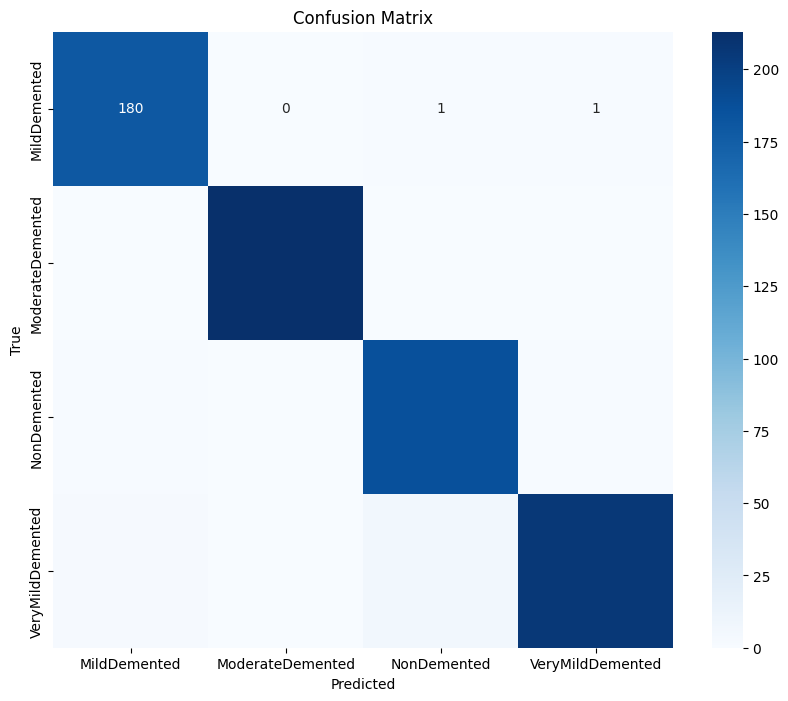

In [19]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import seaborn as sns


true_labels = []
predicted_labels = []

correct = 0
incorrect = 0

for i, (image_batch, label_batch) in enumerate(dataset.take(2000)):
    prediction = model.predict(image_batch)
    
    # Assuming model.predict() returns probabilities for each class
    predicted_index = np.argmax(prediction[0])
    
    predicted_class = class_names[predicted_index]
    actual_class = class_names[label_batch[0]]
    
    print("Predicted:", predicted_class)
    print("Actual:", actual_class)

    if predicted_class == actual_class:
        correct += 1
    else:
        incorrect += 1
    

    true_labels.append(label_batch[0])
    predicted_labels.append(predicted_index)

print(f'{correct} and {incorrect}')


true_labels = np.array(true_labels)
predicted_labels = np.array(predicted_labels)

# Generate confusion matrix
cm = confusion_matrix(true_labels, predicted_labels)

# Plot confusion matrix
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=class_names, yticklabels=class_names)
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix')
plt.show()